# Matemáticas Aplicadas a Ciencia de Datos: Examen 1 — Versión 2

Vamos a utilizar el dataset **MPG (Miles Per Gallon)** que contiene información sobre automóviles fabricados entre 1970 y 1982. El dataset incluye características técnicas de los vehículos como consumo de combustible, número de cilindros, potencia, peso y aceleración.

**Variables principales:**
- `acceleration` : Tiempo de aceleración de 0 a 60 mph en segundos (8.0 - 24.8)
- `mpg` : Millas por galón (consumo de combustible)
- `cylinders` : Número de cilindros (4, 6, 8)
- `displacement` : Cilindrada del motor (pulgadas cúbicas)
- `horsepower` : Caballos de fuerza
- `weight` : Peso del vehículo (libras)
- `model_year` : Año del modelo (70-82)
- `origin` : Origen (usa, europe, japan)
- `name` : Nombre del vehículo

**Alumno:** SAÚL IBRAHIM GARCÍA MORALES


In [1]:
import marimo as mo
from pathlib import Path

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
# Cargar el dataset
url = "https://raw.githubusercontent.com/IvTole/Matematicas_Aplicadas_Ciencia_De_Datos_CUGDL/refs/heads/main/data/cars/mpg.csv"
try:
    df = pd.read_csv("mpg.csv")
except Exception:
    df = pd.read_csv(url)
df_global = df
df.head()


## Funciones de apoyo

Se añaden algunas funciones que los ayudarán a resolver los ejercicios relacionados con distribución gaussiana.

Recuerda que el z-valor puede ser calculado a partir de los datos originales $x$, y viceversa, a partir de las siguientes ecuaciones:

$$z = \frac{x-\mu}{\sigma}; \quad x = z\sigma + \mu$$


In [3]:
## Grafica una distribucion acumulada hasta cierto punto z
def area_cdf(z):
    x = np.arange(-10,z,0.001)
    x_full = np.arange(-10,10,0.001)
    y = stats.norm.pdf(x, 0, 1)
    y_full = stats.norm.pdf(x_full, 0, 1)
    fig, ax = plt.subplots(figsize=(5,3))
    ax.plot(x_full,y_full)
    ax.fill_between(x,y,0, alpha=0.3, color='b')
    ax.fill_between(x_full,y_full,0, alpha=0.1)
    ax.set_xlim([-5,5])
    ax.set_xlabel('z, # de desviaciones estandar con respecto de la media ')
    ax.set_title('Distribución Normal Estándar')
    plt.show()
    area = stats.norm.cdf(z)
    print(f'Area bajo la curva : {area}')
    return area

def area_between(z1,z2):
    x = np.arange(z1,z2,0.001)
    x_full = np.arange(-10,10,0.001)
    y = stats.norm.pdf(x, 0, 1)
    y_full = stats.norm.pdf(x_full, 0, 1)
    fig, ax = plt.subplots(figsize=(5,3))
    ax.plot(x_full,y_full)
    ax.fill_between(x,y,0, alpha=0.3, color='b')
    ax.fill_between(x_full,y_full,0, alpha=0.1)
    ax.set_xlim([-5,5])
    ax.set_xlabel('z, # de desviaciones estandar con respecto de la media ')
    ax.set_title('Distribución Normal Estándar')
    plt.show()
    area = stats.norm.cdf(z2) - stats.norm.cdf(z1)
    print(f'Area bajo la curva : {area}')
    return area

def area_cdf_c(z):
    x = np.arange(z,10,0.001)
    x_full = np.arange(-10,10,0.001)
    y = stats.norm.pdf(x, 0, 1)
    y_full = stats.norm.pdf(x_full, 0, 1)
    fig, ax = plt.subplots(figsize=(5,3))
    ax.plot(x_full,y_full)
    ax.fill_between(x,y,0, alpha=0.3, color='b')
    ax.fill_between(x_full,y_full,0, alpha=0.1)
    ax.set_xlim([-5,5])
    ax.set_xlabel('z, # de desviaciones estandar con respecto de la media ')
    ax.set_title('Distribución Normal Estándar')
    plt.show()
    area = 1.0 - stats.norm.cdf(z)
    print(f'Area bajo la curva : {area}')
    return area


## Análisis Exploratorio de Datos

### Medidas de Tendencia Central y Dispersión

Para la variable **acceleration (tiempo de aceleración 0-60 mph en segundos)**:

**a) Calcula la media, mediana y moda**. Escribe también sus unidades correspondientes.


In [4]:
media = df['acceleration'].mean()
mediana = df['acceleration'].median()
moda = df['acceleration'].mode()

print(f"Media: {media:.2f} segundos")
print(f"Mediana: {mediana:.2f} segundos")
print(f"Moda: {moda[0]} segundos")
media_global = media


Media: 15.57 segundos
Mediana: 15.50 segundos
Moda: 14.5 segundos


**b) Calcula la desviación estándar, varianza y rango intercuartílico (IQR)**. Escribe también sus unidades correspondientes.


In [5]:
desv_est = df['acceleration'].std()
varianza = df['acceleration'].var()
Q1 = df['acceleration'].quantile(0.25)
Q3 = df['acceleration'].quantile(0.75)
IQR = Q3 - Q1

print(f"Desviación Estándar: {desv_est:.2f} segundos")
print(f"Varianza: {varianza:.2f} segundos^2")
print(f"Cuartil 1: {Q1:.2f} segundos")
print(f"Cuartil 3: {Q3:.2f} segundos")
print(f"Rango Intercuartilico: {IQR:.2f} segundos")
desv_global = desv_est


Desviación Estándar: 2.76 segundos
Varianza: 7.60 segundos^2
Cuartil 1: 13.83 segundos
Cuartil 3: 17.18 segundos
Rango Intercuartilico: 3.35 segundos


**c) Interpreta estos resultados: ¿Qué te dicen sobre la aceleración de los automóviles en este dataset?**

*Respuesta:*

Lo que yo puedo concluir de estos datos es que al ser la media y la mediana casi iguales (15.57 y 15.50 respectivamente) la distribucion es practicamente simétrica. Además, los cuartiles me indican que el 75% de los autos tienen una aceleración de 17.18 segundos o menos y el 25% tiene una aceleracion de 13.83 o menos. La desviación estándar de 2.76 segundos nos indica una dispersión moderada entre los autos.


### Visualización

**a) Crea un histograma de la variable acceleration con al menos 10 bins.**


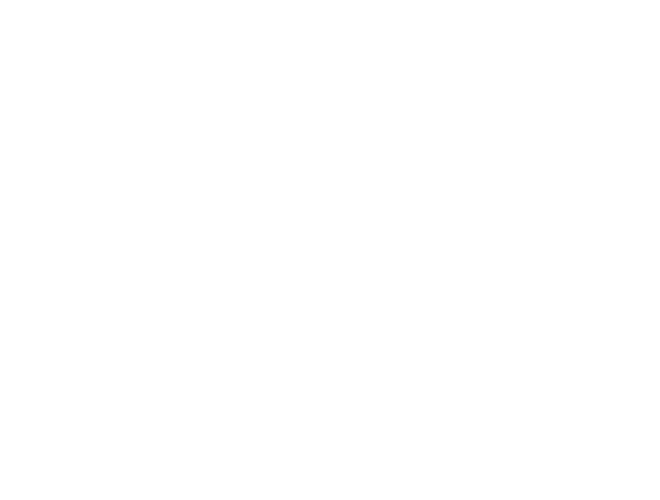

In [6]:
plt.hist(df['acceleration'], bins=10)
plt.ylabel('Cantidad')
plt.xlabel('Aceleración (segundos)')
plt.show()


**b) Crea un boxplot de acceleration. Identifica si existen outliers y menciona cuántos hay.**


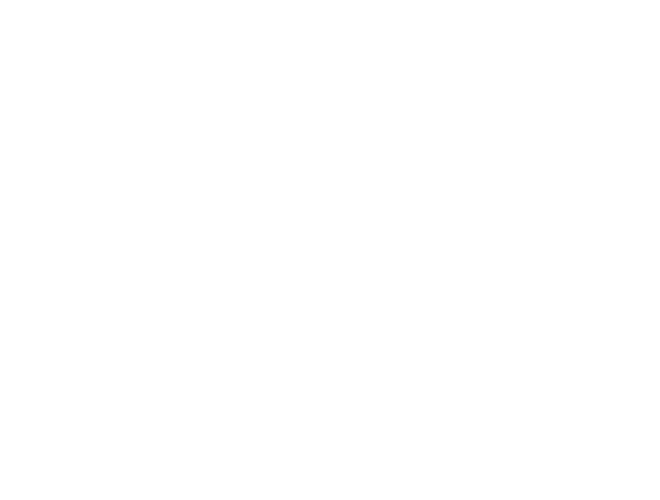

In [7]:
plt.boxplot(df['acceleration'])
plt.show()


*Respuesta:*

Segun este boxplot hay aproximadamente 6 o 7 datos atípicos, que son los puntos que son mayores o menores al calculo de 1.5 x IQR. Hay 3 puntos por debajo del bigote inferior (autos muy rápidos con menos de 8.8 segundos) y 4 puntos por encima del bigote superior (autos muy lentos con más de 22.2 segundos).


**c) Crea un scatter plot entre weight (eje x) y acceleration (eje y). ¿Qué relación observas?**


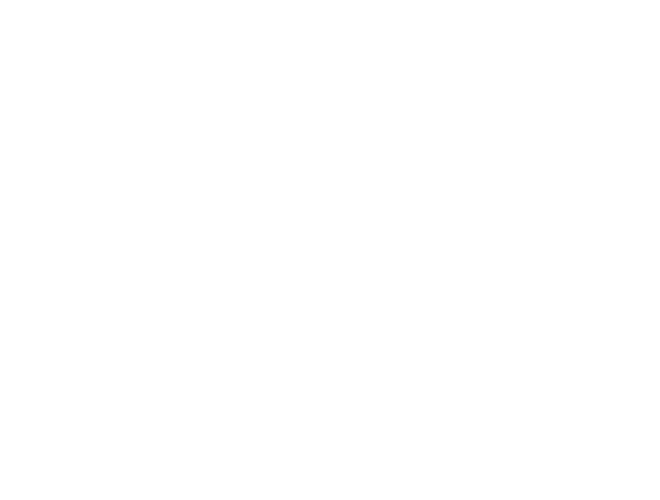

In [8]:
plt.scatter(df['weight'], df['acceleration'])
plt.xlabel('Peso (libras)')
plt.ylabel('Aceleración (segundos)')
plt.show()


*Respuesta:*

En el scatter plot se puede observar que a un mayor peso la aceleración en segundos tiende a disminuir un poco (aceleran más rápido). Aunque hay una considerable dispersión entre los datos, se puede ver como la mayoría de puntos se concentran entre 2000 y 3500 de weight y 13 a 18 de acceleration.


### Análisis de Distribución

**a) Observando el histograma de acceleration, ¿consideras que la distribución es aproximadamente simétrica, sesgada a la derecha o sesgada a la izquierda? Justifica tu respuesta**

*Respuesta:*

Considero que la distribucion es casi simétrica, talvez con un pequeño sesgo a la derecha, aunque es poco notorio. Esto debido a que la mayoría de los datos se distribuyen casi de la misma forma hacia ambos lados del centro, pero del lado derecho se alarga un poco por los autos que tardan más segundos.


**b) Compara la media y la mediana de acceleration. ¿Qué te indica esta comparación sobre la simetría de los datos?**

*Respuesta:*

Me indica que son simétricos, pues los valores de la media y la mediana son casi iguales (15.57 y 15.50 segundos).


## Distribución Gaussiana

### Ajuste de Distribución Normal

Considera la variable **acceleration (tiempo de aceleración)**.

**a) Estima los parámetros μ (media) y σ (desviación estándar) de una distribución normal que se ajuste a los datos de acceleration.**


In [9]:
mu = media
sigma = desv_est
print(f"mu = {mu:.2f}")
print(f"sigma = {sigma:.2f}")
mu_global = mu
sigma_global = sigma


mu = 15.57
sigma = 2.76


**b) Crea un gráfico que superponga:**
- **El histograma normalizado (densidad) de acceleration**
- **La curva de la distribución normal N(μ, σ²) con los parámetros estimados**


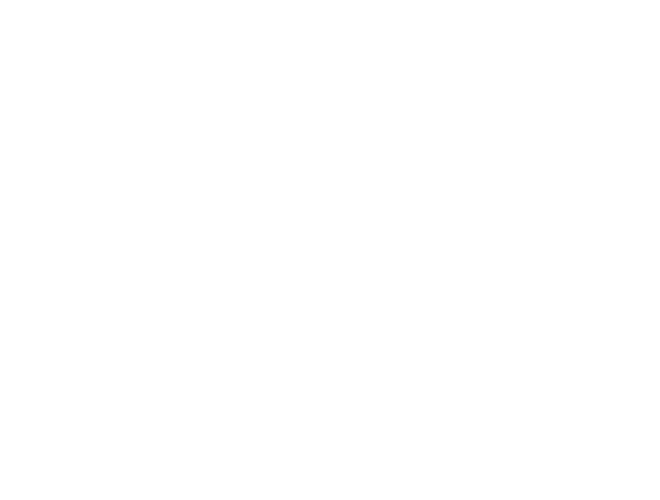

In [10]:
dist = stats.norm(loc=mu, scale=sigma)
x = np.arange(7, 25, 0.1)
P_x = dist.pdf(x)
plt.hist(df['acceleration'], bins=15, density=True)
plt.plot(x, P_x)
plt.show()


**c) Crea un gráfico Q-Q (quantile-quantile plot) para evaluar qué tan bien se ajusta acceleration a una distribución normal. ¿Los datos siguen aproximadamente una distribución normal? Justifica.**


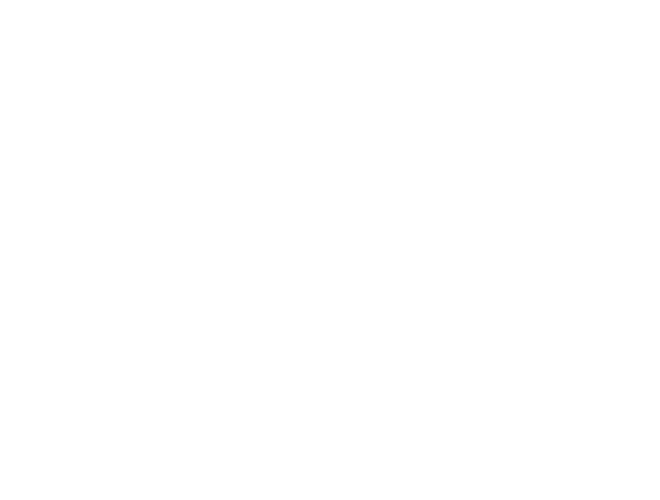

In [11]:
stats.probplot(df['acceleration'], dist="norm", plot=plt)
plt.show()


*Respuesta:*

Considero que si siguen una distribución normal. Como podemos ver en el grafico, los valores siguen casi a la perfeccion la recta roja a excepcion de unos pocos valores en la cola superior.


### Cálculo de Probabilidades

Asumiendo que acceleration sigue una distribución normal con los parámetros estimados en el punto anterior, utiliza las funciones de apoyo `area_cdf`, `area_cdf_c` y `area_between`, según corresponda. Para los percentiles, utiliza la función `stats.norm.ppf` de scipy.

**a) ¿Cuál es la probabilidad de que un automóvil seleccionado al azar tarde menos de 13 segundos en acelerar de 0 a 60 mph?**


-0.9312473297834039
Area bajo la curva : 0.17586282013039417


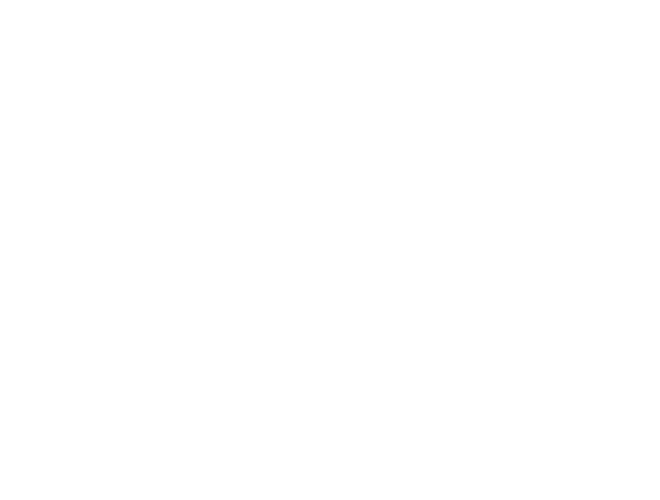

In [12]:
z_p1 = (13 - mu) / sigma
print(z_p1)
area_cdf(z_p1)


*Respuesta:*

La probabilidad de que un automovil tarde menos de 13 segundos es de aproximadamente 17.59% (area: 0.1759).


**b) ¿Cuál es la probabilidad de que un automóvil seleccionado al azar tarde entre 15 y 19 segundos en acelerar de 0 a 60 mph?**


Area bajo la curva : 0.47494538075222903


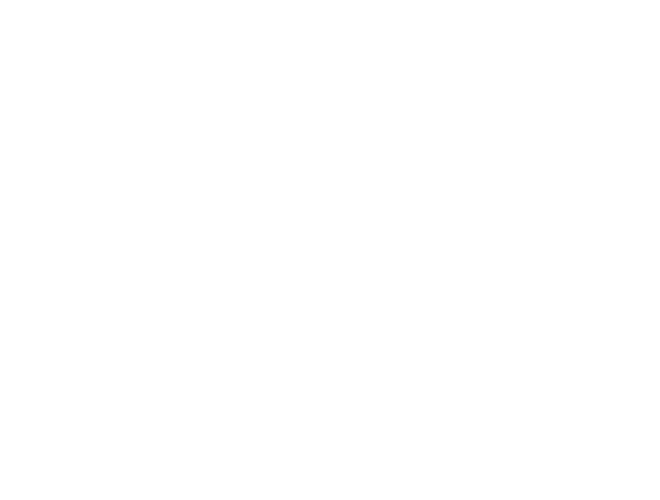

In [13]:
z_p2_1 = (15 - mu) / sigma
z_p2_2 = (19 - mu) / sigma
area_between(z_p2_1, z_p2_2)


*Respuesta:*

La probabilidad de que un automovil tarde entre 15 y 19 segundos es del 47.49% (area: 0.4749).


**c) Se clasificará como de "aceleración lenta" al 20% de los automóviles con los mayores tiempos de aceleración de 0 a 60 mph. ¿Cuál es el tiempo límite a partir del cual un automóvil pertenece a esta clasificación?**


In [14]:
z_p3 = stats.norm().ppf(0.80)
x_p3 = mu + (z_p3 * sigma)
print(x_p3)


17.889020011180623


*Respuesta:*

El tiempo limite para pertenecer a la clasificacion de aceleracion lenta (el 20% con mayores tiempos, percentil 80) es de 17.89 segundos. Los autos que tardan 17.89 segundos o mas son considerados lentos.


**d) ¿Cuál es la probabilidad de que un automóvil seleccionado al azar tarde más de 17 segundos en acelerar de 0 a 60 mph?**


Area bajo la curva : 0.30179579053801


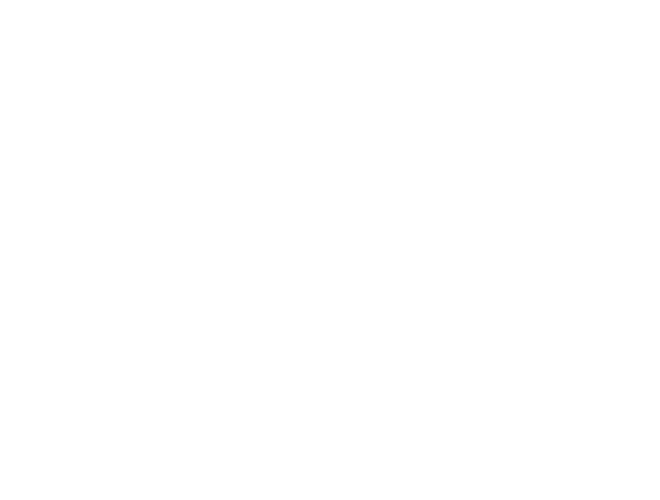

In [15]:
z_p4 = (17 - mu) / sigma
area_cdf_c(z_p4)


*Respuesta:*

La probabilidad de que un automovil tarde mas de 17 segundos es del 30.18% (area: 0.3018).


### Interpretación y Aplicación

**a) Suponiendo que los tiempos de aceleración de 0 a 60 mph de un lote de 800 automóviles siguen el modelo gaussiano ajustado, ¿aproximadamente cuántos automóviles esperarías que tengan tiempos entre 13 y 16 segundos? Utiliza las funciones de apoyo y explica cómo conviertes la probabilidad en un número esperado de automóviles.**


Area bajo la curva : 0.3863650541428241
Esperados: 309.0920433142593


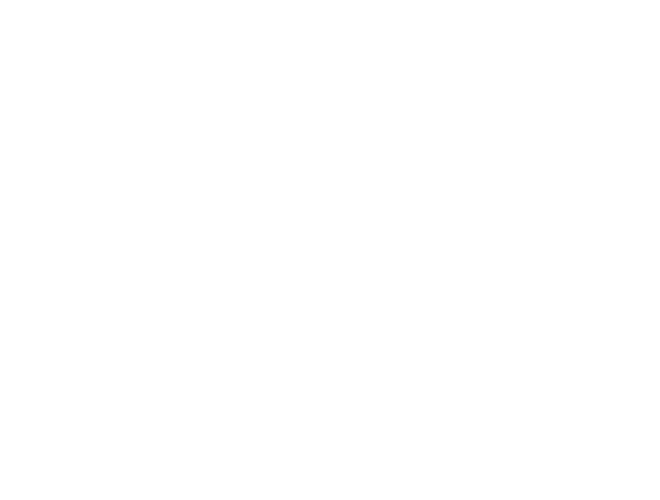

In [16]:
z_p5_1 = (13 - mu) / sigma
z_p5_2 = (16 - mu) / sigma
prob = area_between(z_p5_1, z_p5_2)
print("Esperados:", prob * 800)


*Respuesta:*

Aproximadamente 309 automoviles (0.3864 * 800 = 309.1). Convierto la probabilidad multiplicando la probabilidad que obtuvimos del area entre 13 y 16 segundos por el total de autos del lote (800).


**b) Una revista de automóviles quiere seleccionar el 10% de autos con mejor aceleración (menor tiempo de 0 a 60 mph) para una categoría especial. Según el modelo gaussiano ajustado, ¿cuál debería ser el tiempo máximo para calificar? Utiliza `stats.norm.ppf` y expresa el resultado en segundos.**


In [17]:
z_p6 = stats.norm().ppf(0.10)
x_p6 = mu + (z_p6 * sigma)
print(x_p6)


12.033969886974859


*Respuesta:*

El tiempo maximo para calificar es de aproximadamente 12.03 segundos.


**c) Reflexiona: ¿Consideras que el modelo de distribución normal es apropiado para modelar la aceleración de los automóviles? ¿Qué limitaciones podría tener este modelo?**

*Respuesta:*

Considero que el modelo de distribución normal si es apropiado para modelar la aceleración de los automoviles, pues al ser datos continuos se adaptan mejor a este modelo y los datos son bastante simetricos. Una de las limitaciones que puede tener es que en la distribucion normal existen valores negativos, pero en la vida real el tiempo de aceleracion siempre es un numero positivo.


## Criterios de Evaluación

- **Justificación matemática y estadística**: 50%
- **Calidad del código y visualizaciones**: 25%
- **Interpretación y análisis crítico**: 25%

**Total: 100 puntos**
